Optuna best (penalized CV f1_macro): 0.6527

Best hyperparameters:
  n_estimators: 566
  max_depth: 4
  learning_rate: 0.016904354473006616
  subsample: 0.5076120140492416
  colsample_bytree: 0.5822226430459514
  min_child_weight: 12.1194766522641
  gamma: 0.2297714438621048
  reg_alpha: 7.3975242302455415
  reg_lambda: 4.616698381405631
  max_delta_step: 0.34911430074410355
  grow_policy: lossguide


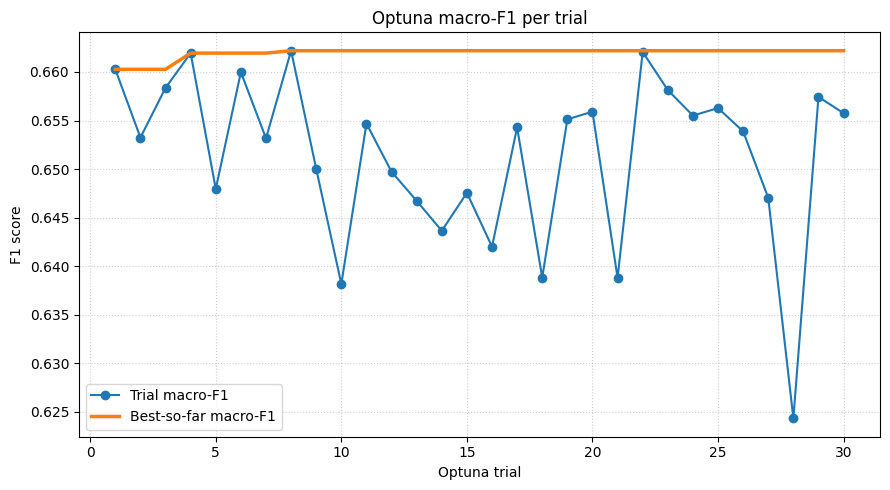

C:\Users\mehramah\AppData\Local\Temp\ipykernel_13468\2640157876.py:492: FutureWarning: Starting with pandas version 3.0 all arguments of to_excel except for the argument 'excel_writer' will be keyword-only.
  study.trials_dataframe().to_excel(writer, "optuna_trials", index=False)
C:\Users\mehramah\AppData\Local\Temp\ipykernel_13468\2640157876.py:502: FutureWarning: Starting with pandas version 3.0 all arguments of to_excel except for the argument 'excel_writer' will be keyword-only.
  metrics_summary_df.to_excel(writer, "metrics_summary")
C:\Users\mehramah\AppData\Local\Temp\ipykernel_13468\2640157876.py:504: FutureWarning: Starting with pandas version 3.0 all arguments of to_excel except for the argument 'excel_writer' will be keyword-only.
  pd.DataFrame(per_fold_overall_rows).to_excel(writer, "metrics_per_fold", index=False)
C:\Users\mehramah\AppData\Local\Temp\ipykernel_13468\2640157876.py:505: FutureWarning: Starting with pandas version 3.0 all arguments of to_excel except for the


Done. Results saved under: C:\Users\mehramah\Downloads\manualclassification\databseforecologi\Paper1dataset\dataset\Dataset\new\new\xg\multi\XGB_4classmodel_results.xlsx
Output folder: C:\Users\mehramah\Downloads\manualclassification\databseforecologi\Paper1dataset\dataset\Dataset\new\new\xg\multi


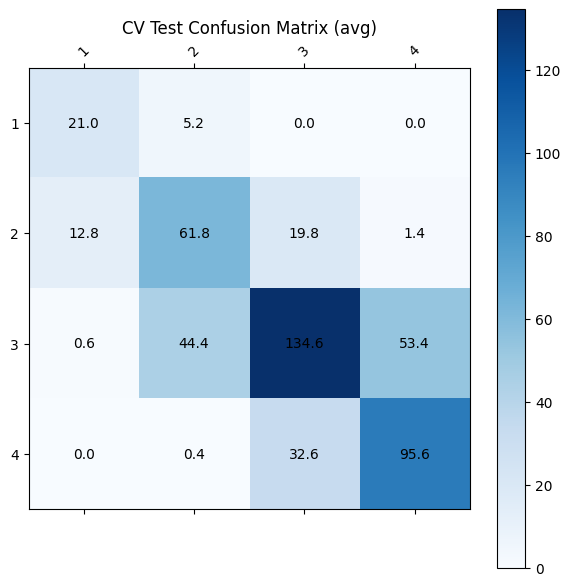

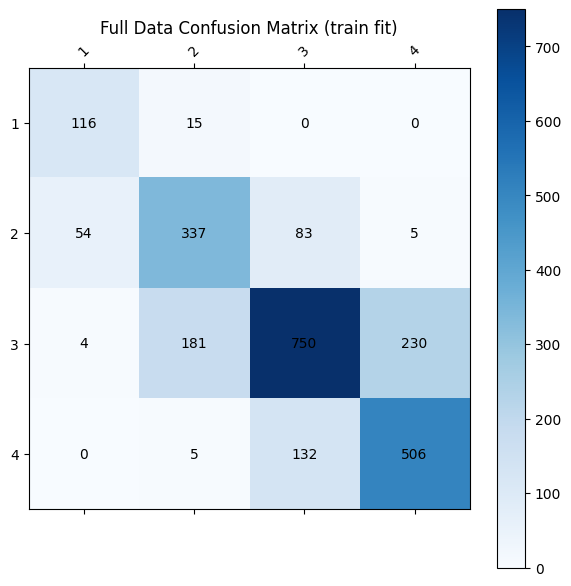

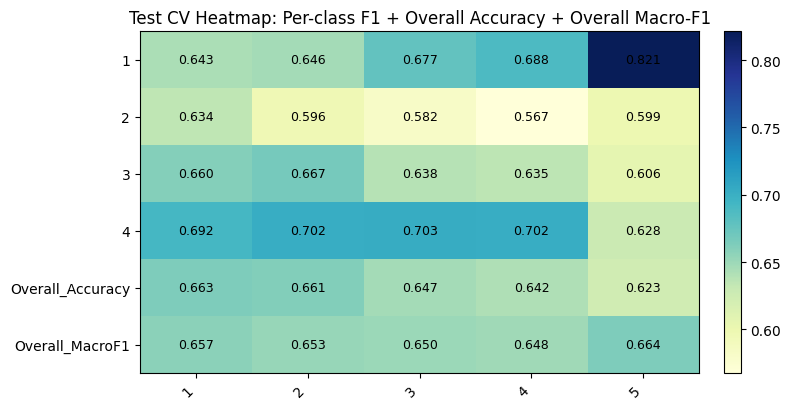

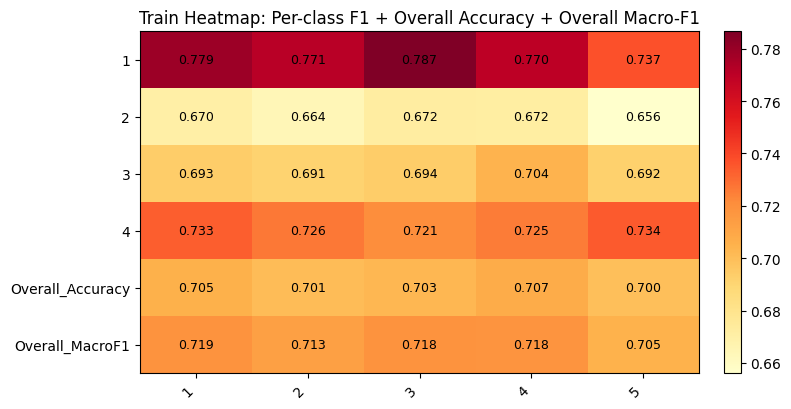

In [10]:
# ============================================================
# XGBOOST + OPTUNA + CLASS WEIGHTS (NO OVERSAMPLING)
# + 5-FOLD CROSS-VALIDATION
# + FULL EXCEL OUTPUT + HEATMAPS + CONFUSION MATRICES
#
# ✅ Broadened Optuna Hyperparameter Search Space
# ✅ ALL PLOTS NOW DISPLAY INTERACTIVELY (plt.show())
# ✅ Fixed KeyError for dictionary mappings
# ============================================================

import os
import numpy as np
import pandas as pd
import optuna
import matplotlib.pyplot as plt
import warnings

from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, matthews_corrcoef
)
from collections import Counter
from xgboost import XGBClassifier

# Suppress Optuna experimental warnings for cleaner output
warnings.filterwarnings("ignore", category=optuna.exceptions.ExperimentalWarning)

# ================================
# USER SETTINGS
# ================================
RANDOM_STATE = 42
N_SPLITS = 5

# INCREASED trials because the search space is now much larger
N_TRIALS = 30
N_STARTUP_RANDOM = 10

F1_GAP_THRESHOLD = 0.06
GAP_PENALTY_ALPHA = 5.0

DATA_PATH = r"C:\Users\mehramah\Downloads\manualclassification\databseforecologi\Paper1dataset\dataset\Dataset\new\imputedmulti.txt"
OUTPUT_DIR = r"C:\Users\mehramah\Downloads\manualclassification\databseforecologi\Paper1dataset\dataset\Dataset\new\new\xg\multi"

output_base = OUTPUT_DIR
os.makedirs(output_base, exist_ok=True)
excel_path = os.path.join(output_base, "XGB_4classmodel_results.xlsx")


# ================================
# DATA
# ================================
ultimate4 = pd.read_csv(DATA_PATH, sep="\t")
df = ultimate4.dropna().reset_index(drop=True)

features = [
    'meanTP', 'meanTN', 'meanTurb', 'meanWC', 'meanCond',
    'thermal_class',
    'bottom_DO_min', 'surface_DO_min', 'bottom_pH_min',
    'surface_pH_max', 'area_m2', 'SECCIDEPTH', 'NEWDEPTH',
    'tyyppi_Lv', 'tyyppi_Kh', 'tyyppi_Mh', 'tyyppi_MRh',
    'tyyppi_MVh', 'tyyppi_Ph', 'tyyppi_Vh', 'tyyppi_PoLa', 'tyyppi_Rh',
    'tyyppi_Rk', 'tyyppi_Rr', 'tyyppi_Sh', 'tyyppi_SVh'
]
target_col = "ecologystatus"

X = df[features].reset_index(drop=True)
y = df[target_col].reset_index(drop=True)
lakecode = df["LakeCode"].reset_index(drop=True)

le = LabelEncoder()
y_enc = le.fit_transform(y)
class_names = le.classes_
N_CLASSES = len(class_names)

XGB_OBJECTIVE = "multi:softprob" if N_CLASSES > 2 else "binary:logistic"

cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)


# ================================
# CLASS WEIGHT HELPERS
# ================================
def compute_balanced_class_weights(y_encoded):
    y_encoded = np.asarray(y_encoded)
    counts = Counter(y_encoded)
    n = len(y_encoded)
    k = len(counts)
    return {c: n / (k * cnt) for c, cnt in counts.items()}

def make_sample_weight_vector(y_encoded, class_weight_dict):
    y_encoded = np.asarray(y_encoded)
    return np.array([class_weight_dict[int(c)] for c in y_encoded], dtype=np.float32)


# ================================
# HEATMAP HELPER (UPDATED WITH plt.show())
# ================================
def save_heatmap(df_plot, title, save_path, cmap="YlGnBu", fmt=".3f"):
    arr = df_plot.values.astype(float)

    fig_w = max(8, 1.2 * df_plot.shape[1])
    fig_h = max(4, 0.7 * df_plot.shape[0])

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    im = ax.imshow(arr, cmap=cmap, aspect="auto")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    ax.set_xticks(np.arange(df_plot.shape[1]))
    ax.set_yticks(np.arange(df_plot.shape[0]))
    ax.set_xticklabels(df_plot.columns, rotation=45, ha="right")
    ax.set_yticklabels(df_plot.index)
    ax.set_title(title)

    for i in range(df_plot.shape[0]):
        for j in range(df_plot.shape[1]):
            ax.text(j, i, format(arr[i, j], fmt), ha="center", va="center", fontsize=9)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()  # <--- Forces the heatmap to pop up
    plt.close()


# ================================
# PER-CLASS MCC (OVR)
# ================================
def per_class_mcc(y_true, y_pred, classes):
    out = {}
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    for c in classes:
        out[c] = matthews_corrcoef((y_true == c).astype(int), (y_pred == c).astype(int))
    return out


# ============================================================
# 1) OPTUNA TUNING (WIDENED SEARCH SPACE)
# ============================================================
def make_objective(X, y, cv):
    def objective(trial):
        # WIDENED SEARCH SPACE for better exploration
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
            "max_depth": trial.suggest_int("max_depth", 3, 10),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            "subsample": trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
            "min_child_weight": trial.suggest_float("min_child_weight", 1.0, 20.0),
            "gamma": trial.suggest_float("gamma", 0.0, 5.0),
            "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 10.0),
            "reg_lambda": trial.suggest_float("reg_lambda", 0.01, 10.0, log=True),
            "max_delta_step": trial.suggest_float("max_delta_step", 0.0, 10.0),
            "grow_policy": trial.suggest_categorical("grow_policy", ["depthwise", "lossguide"]),
        }

        xgb = XGBClassifier(
            **params,
            objective=XGB_OBJECTIVE,
            eval_metric="mlogloss" if N_CLASSES > 2 else "logloss",
            n_jobs=-1,
            random_state=RANDOM_STATE,
            tree_method="hist",
            verbosity=0,
            num_class=N_CLASSES if N_CLASSES > 2 else None
        )

        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("xgb", xgb)
        ])

        train_f1s, val_f1s = [], []

        for ti, vi in cv.split(X, y):
            X_tr, X_val = X.iloc[ti], X.iloc[vi]
            y_tr, y_val = y[ti], y[vi]

            cw = compute_balanced_class_weights(y_tr)
            w_tr = make_sample_weight_vector(y_tr, cw)

            pipe.fit(X_tr, y_tr, xgb__sample_weight=w_tr)

            y_pred_tr = pipe.predict(X_tr)
            y_pred_va = pipe.predict(X_val)

            train_f1s.append(f1_score(y_tr, y_pred_tr, average="macro", zero_division=0))
            val_f1s.append(f1_score(y_val, y_pred_va, average="macro", zero_division=0))

        mean_train_f1 = float(np.mean(train_f1s))
        mean_val_f1 = float(np.mean(val_f1s))
        gap = mean_train_f1 - mean_val_f1

        trial.set_user_attr("cv_test_f1_mean", mean_val_f1)
        trial.set_user_attr("cv_test_f1_std", float(np.std(val_f1s)))
        trial.set_user_attr("cv_train_f1_mean", mean_train_f1)
        trial.set_user_attr("cv_f1_gap", gap)

        penalized = mean_val_f1
        if gap > F1_GAP_THRESHOLD:
            penalized = max(mean_val_f1 - GAP_PENALTY_ALPHA * (gap - F1_GAP_THRESHOLD), 0.0)

        trial.set_user_attr("cv_penalized_score", penalized)
        return penalized

    return objective


opt_sampler = optuna.samplers.TPESampler(
    seed=RANDOM_STATE,
    n_startup_trials=N_STARTUP_RANDOM,
    multivariate=True
)

study = optuna.create_study(direction="maximize", sampler=opt_sampler)
study.optimize(make_objective(X, y_enc, cv), n_trials=N_TRIALS)

best_bayes = study.best_params
print("Optuna best (penalized CV f1_macro):", f"{study.best_value:.4f}")
print("\nBest hyperparameters:")
for k, v in best_bayes.items():
    print(f"  {k}: {v}")

# -------------------------------
# Optuna F1 per trial plot
# -------------------------------
trial_numbers = []
trial_f1 = []
trial_best_so_far = []

best_so_far = -np.inf
for t in study.trials:
    if t.value is None:
        continue
    trial_numbers.append(t.number + 1)
    this_f1 = t.user_attrs.get("cv_test_f1_mean", t.value)
    trial_f1.append(this_f1)
    best_so_far = max(best_so_far, this_f1)
    trial_best_so_far.append(best_so_far)

plt.figure(figsize=(9, 5))
plt.plot(trial_numbers, trial_f1, marker="o", linewidth=1.5, label="Trial macro-F1")
plt.plot(trial_numbers, trial_best_so_far, linewidth=2.5, label="Best-so-far macro-F1")
plt.xlabel("Optuna trial")
plt.ylabel("F1 score")
plt.title("Optuna macro-F1 per trial")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_base, "optuna_f1_per_trial.png"), dpi=300)
plt.show()  # <--- Displays Optuna plot
plt.close()

best_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("xgb", XGBClassifier(
        **best_bayes,
        objective=XGB_OBJECTIVE,
        eval_metric="mlogloss" if N_CLASSES > 2 else "logloss",
        n_jobs=-1,
        random_state=RANDOM_STATE,
        tree_method="hist",
        verbosity=0,
        num_class=N_CLASSES if N_CLASSES > 2 else None
    ))
])


# ============================================================
# 2) MANUAL 5-FOLD CV (NO CALIBRATION, NO PERMUTATION)
# ============================================================
metrics = {"accuracy": [], "precision": [], "recall": [], "f1": [], "mcc": []}
conf_matrices = {"train": [], "test_cv": []}
train_preds, test_cv_preds = [], []
train_class_reports, test_cv_class_reports = [], []
per_fold_overall_rows, per_fold_perclass_rows = [], []

for fold, (ti, vi) in enumerate(cv.split(X, y_enc), 1):
    X_tr, X_te = X.iloc[ti].copy(), X.iloc[vi].copy()
    y_tr, y_te = y_enc[ti], y_enc[vi]
    lakecode_tr = lakecode.iloc[ti].reset_index(drop=True)
    lakecode_te = lakecode.iloc[vi].reset_index(drop=True)

    cw = compute_balanced_class_weights(y_tr)
    w_tr = make_sample_weight_vector(y_tr, cw)

    model = clone(best_pipe)
    model.fit(X_tr, y_tr, xgb__sample_weight=w_tr)

    # train predictions + probs
    y_pred_tr = model.predict(X_tr)
    y_proba_tr = model.predict_proba(X_tr)

    df_tr = pd.DataFrame(X_tr, columns=features)
    df_tr["actual"] = le.inverse_transform(y_tr)
    df_tr["pred"] = le.inverse_transform(y_pred_tr)
    df_tr["fold"] = fold
    df_tr["LakeCode"] = lakecode_tr.values
    for idx, cls in enumerate(np.unique(y_enc)):
        class_label = le.inverse_transform([cls])[0]
        df_tr[f"proba_{class_label}"] = y_proba_tr[:, idx]
    df_tr["is_synthetic"] = False
    train_preds.append(df_tr)

    # outer test predictions + probs
    y_pred_te = model.predict(X_te)
    y_proba_te = model.predict_proba(X_te)

    df_te = pd.DataFrame(X_te, columns=features)
    df_te["actual"] = le.inverse_transform(y_te)
    df_te["pred"] = le.inverse_transform(y_pred_te)
    df_te["fold"] = fold
    df_te["LakeCode"] = lakecode_te.values
    for idx, cls in enumerate(np.unique(y_enc)):
        class_label = le.inverse_transform([cls])[0]
        df_te[f"proba_{class_label}"] = y_proba_te[:, idx]
    df_te["is_synthetic"] = False
    test_cv_preds.append(df_te)

    # overall metrics
    acc_te = accuracy_score(y_te, y_pred_te)
    prec_te = precision_score(y_te, y_pred_te, average="macro", zero_division=0)
    rec_te = recall_score(y_te, y_pred_te, average="macro", zero_division=0)
    f1_te = f1_score(y_te, y_pred_te, average="macro", zero_division=0)
    mcc_te = matthews_corrcoef(y_te, y_pred_te)

    acc_tr = accuracy_score(y_tr, y_pred_tr)
    prec_tr = precision_score(y_tr, y_pred_tr, average="macro", zero_division=0)
    rec_tr = recall_score(y_tr, y_pred_tr, average="macro", zero_division=0)
    f1_tr = f1_score(y_tr, y_pred_tr, average="macro", zero_division=0)
    mcc_tr = matthews_corrcoef(y_tr, y_pred_tr)

    metrics["accuracy"].append((acc_te, acc_tr))
    metrics["precision"].append((prec_te, prec_tr))
    metrics["recall"].append((rec_te, rec_tr))
    metrics["f1"].append((f1_te, f1_tr))
    metrics["mcc"].append((mcc_te, mcc_tr))

    per_fold_overall_rows.append({
        "fold": fold, "dataset": "test_cv",
        "accuracy": acc_te, "precision_macro": prec_te, "recall_macro": rec_te,
        "f1_macro": f1_te, "mcc": mcc_te
    })
    per_fold_overall_rows.append({
        "fold": fold, "dataset": "train_original",
        "accuracy": acc_tr, "precision_macro": prec_tr, "recall_macro": rec_tr,
        "f1_macro": f1_tr, "mcc": mcc_tr
    })

    conf_matrices["test_cv"].append(confusion_matrix(y_te, y_pred_te, labels=np.unique(y_enc)))
    conf_matrices["train"].append(confusion_matrix(y_tr, y_pred_tr, labels=np.unique(y_enc)))

    # per-class report
    rpt_cv_te = classification_report(
        [str(x) for x in le.inverse_transform(y_te)],
        [str(x) for x in le.inverse_transform(y_pred_te)],
        output_dict=True, zero_division=0
    )
    rpt_cv_tr = classification_report(
        [str(x) for x in le.inverse_transform(y_tr)],
        [str(x) for x in le.inverse_transform(y_pred_tr)],
        output_dict=True, zero_division=0
    )

    # per-class MCC
    mcc_pc_te = per_class_mcc(y_te, y_pred_te, np.unique(y_enc))
    mcc_pc_tr = per_class_mcc(y_tr, y_pred_tr, np.unique(y_enc))

    df_rpt_te = pd.DataFrame(rpt_cv_te).T.reset_index().rename(columns={"index": "class"})
    df_rpt_te["fold"] = fold
    df_rpt_te["dataset"] = "test_cv"
    df_rpt_te["mcc_ovr"] = df_rpt_te["class"].map({
        str(le.inverse_transform([c])[0]): mcc_pc_te[c] for c in np.unique(y_enc)
    })
    test_cv_class_reports.append(df_rpt_te)

    df_rpt_tr = pd.DataFrame(rpt_cv_tr).T.reset_index().rename(columns={"index": "class"})
    df_rpt_tr["fold"] = fold
    df_rpt_tr["dataset"] = "train_original"
    df_rpt_tr["mcc_ovr"] = df_rpt_tr["class"].map({
        str(le.inverse_transform([c])[0]): mcc_pc_tr[c] for c in np.unique(y_enc)
    })
    train_class_reports.append(df_rpt_tr)

    true_class_labels = list(le.classes_)
    for cls_label in true_class_labels:
        str_cls = str(cls_label)
        
        if str_cls in rpt_cv_te:
            per_fold_perclass_rows.append({
                "fold": fold, "dataset": "test_cv", "class": cls_label,
                "precision": rpt_cv_te[str_cls]["precision"],
                "recall": rpt_cv_te[str_cls]["recall"],
                "f1": rpt_cv_te[str_cls]["f1-score"],
                "support": rpt_cv_te[str_cls]["support"],
                "mcc_ovr": df_rpt_te.loc[df_rpt_te["class"] == str_cls, "mcc_ovr"].values[0]
            })
        if str_cls in rpt_cv_tr:
            per_fold_perclass_rows.append({
                "fold": fold, "dataset": "train_original", "class": cls_label,
                "precision": rpt_cv_tr[str_cls]["precision"],
                "recall": rpt_cv_tr[str_cls]["recall"],
                "f1": rpt_cv_tr[str_cls]["f1-score"],
                "support": rpt_cv_tr[str_cls]["support"],
                "mcc_ovr": df_rpt_tr.loc[df_rpt_tr["class"] == str_cls, "mcc_ovr"].values[0]
            })


# ============================================================
# 2B) HEATMAP TABLES: PER-CLASS F1 + OVERALL ACCURACY + OVERALL MACRO-F1
# ============================================================
per_class_df = pd.DataFrame(per_fold_perclass_rows)
overall_df = pd.DataFrame(per_fold_overall_rows)

# TEST heatmap table
test_f1_heat = (
    per_class_df[per_class_df["dataset"] == "test_cv"]
    .pivot(index="class", columns="fold", values="f1")
    .copy()
)
test_acc_row = (
    overall_df[overall_df["dataset"] == "test_cv"]
    .set_index("fold")["accuracy"]
)
test_macrof1_row = (
    overall_df[overall_df["dataset"] == "test_cv"]
    .set_index("fold")["f1_macro"]
)

test_f1_heat.loc["Overall_Accuracy"] = test_acc_row
test_f1_heat.loc["Overall_MacroF1"] = test_macrof1_row

# TRAIN heatmap table
train_f1_heat = (
    per_class_df[per_class_df["dataset"] == "train_original"]
    .pivot(index="class", columns="fold", values="f1")
    .copy()
)
train_acc_row = (
    overall_df[overall_df["dataset"] == "train_original"]
    .set_index("fold")["accuracy"]
)
train_macrof1_row = (
    overall_df[overall_df["dataset"] == "train_original"]
    .set_index("fold")["f1_macro"]
)

train_f1_heat.loc["Overall_Accuracy"] = train_acc_row
train_f1_heat.loc["Overall_MacroF1"] = train_macrof1_row


# ============================================================
# 3) FINAL MODEL TRAINED ON ALL DATA (REFERENCE)
# ============================================================
cw_full = compute_balanced_class_weights(y_enc)
w_full = make_sample_weight_vector(y_enc, cw_full)

final_model = clone(best_pipe)
final_model.fit(X, y_enc, xgb__sample_weight=w_full)

y_full_pred = final_model.predict(X)
y_full_pred_labels = le.inverse_transform(y_full_pred)
proba_full = final_model.predict_proba(X)

full_data_metrics = {
    "accuracy": float(accuracy_score(y_enc, y_full_pred)),
    "precision": float(precision_score(y_enc, y_full_pred, average="macro", zero_division=0)),
    "recall": float(recall_score(y_enc, y_full_pred, average="macro", zero_division=0)),
    "f1": float(f1_score(y_enc, y_full_pred, average="macro", zero_division=0)),
    "mcc": float(matthews_corrcoef(y_enc, y_full_pred))
}

cm_full = confusion_matrix(y_enc, y_full_pred, labels=np.unique(y_enc))

df_full = X.copy()
df_full["actual"] = y
df_full["pred"] = y_full_pred_labels
df_full["LakeCode"] = lakecode
for idx, cls in enumerate(np.unique(y_enc)):
    class_label = le.inverse_transform([cls])[0]
    df_full[f"proba_{class_label}"] = proba_full[:, idx]
df_full["is_synthetic"] = False


# ============================================================
# 4) SAVE RESULTS TO EXCEL
# ============================================================
with pd.ExcelWriter(excel_path, engine="xlsxwriter") as writer:
    study.trials_dataframe().to_excel(writer, "optuna_trials", index=False)

    metrics_summary_df = pd.DataFrame.from_dict({
        m: {
            "test_mean": np.mean([x[0] for x in metrics[m]]),
            "test_std": np.std([x[0] for x in metrics[m]]),
            "train_mean": np.mean([x[1] for x in metrics[m]]),
            "train_std": np.std([x[1] for x in metrics[m]])
        } for m in metrics
    }, orient="index")
    metrics_summary_df.to_excel(writer, "metrics_summary")

    pd.DataFrame(per_fold_overall_rows).to_excel(writer, "metrics_per_fold", index=False)
    pd.DataFrame(per_fold_perclass_rows).to_excel(writer, "metrics_per_class_fold", index=False)

    test_f1_heat.to_excel(writer, "heatmap_test_f1")
    train_f1_heat.to_excel(writer, "heatmap_train_f1")

    pd.DataFrame(sum(conf_matrices["test_cv"]) / len(conf_matrices["test_cv"]),
                 columns=class_names, index=class_names).to_excel(writer, "confusion_cv_test")
    pd.DataFrame(sum(conf_matrices["train"]) / len(conf_matrices["train"]),
                 columns=class_names, index=class_names).to_excel(writer, "confusion_cv_train")

    pd.concat(train_class_reports, ignore_index=True).to_excel(writer, "cv_train_class_report", index=False)
    pd.concat(test_cv_class_reports, ignore_index=True).to_excel(writer, "cv_test_class_report", index=False)

    pd.DataFrame([full_data_metrics]).to_excel(writer, "evaluation_full_data", index=False)
    pd.DataFrame(cm_full, columns=class_names, index=class_names).to_excel(writer, "confusion_full_data")

    pd.concat(train_preds, ignore_index=True).to_excel(writer, "cv_train_predictions", index=False)
    pd.concat(test_cv_preds, ignore_index=True).to_excel(writer, "cv_test_predictions", index=False)
    df_full.to_excel(writer, "predictions_full_data", index=False)

print(f"\nDone. Results saved under: {excel_path}")
print(f"Output folder: {output_base}")


# ============================================================
# 5) PLOTS (confusion + heatmaps)
# ============================================================
# Confusion matrix (CV test avg)
cm_cv = sum(conf_matrices["test_cv"]) / len(conf_matrices["test_cv"])
fig, ax = plt.subplots(figsize=(6, 6))
im = ax.matshow(cm_cv, cmap="Blues")
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(class_names)))
ax.set_yticks(range(len(class_names)))
ax.set_xticklabels(class_names, rotation=45)
ax.set_yticklabels(class_names)
for i in range(cm_cv.shape[0]):
    for j in range(cm_cv.shape[1]):
        ax.text(j, i, f"{cm_cv[i, j]:.1f}", va="center", ha="center")
plt.title("CV Test Confusion Matrix (avg)")
plt.tight_layout()
plt.savefig(os.path.join(output_base, "cm_cv_test.png"), dpi=300)
plt.show()  # <--- Displays CV Confusion Matrix
plt.close()

# Confusion matrix (full data)
fig, ax = plt.subplots(figsize=(6, 6))
im = ax.matshow(cm_full, cmap="Blues")
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(class_names)))
ax.set_yticks(range(len(class_names)))
ax.set_xticklabels(class_names, rotation=45)
ax.set_yticklabels(class_names)
for i in range(cm_full.shape[0]):
    for j in range(cm_full.shape[1]):
        ax.text(j, i, f"{cm_full[i, j]}", va="center", ha="center")
plt.title("Full Data Confusion Matrix (train fit)")
plt.tight_layout()
plt.savefig(os.path.join(output_base, "cm_full.png"), dpi=300)
plt.show()  # <--- Displays Full Data Confusion Matrix
plt.close()

# Heatmaps
save_heatmap(
    test_f1_heat,
    title="Test CV Heatmap: Per-class F1 + Overall Accuracy + Overall Macro-F1",
    save_path=os.path.join(output_base, "heatmap_test_f1.png"),
    cmap="YlGnBu",
    fmt=".3f"
)

save_heatmap(
    train_f1_heat,
    title="Train Heatmap: Per-class F1 + Overall Accuracy + Overall Macro-F1",
    save_path=os.path.join(output_base, "heatmap_train_f1.png"),
    cmap="YlOrRd",
    fmt=".3f"
)